# OpenVLA

OpenVLA 的贡献：<mark>**高效微调与部署方法**</mark>

OpenVLA 不是 RT-2 的复刻，只是高层配方相同——骨干、视觉编码器、数据、离散化都换了。

论文自己声明的贡献大致是四块（原文依据）：

1. 提出一个 7B 的开源 VLA，在 970k 条 OpenX 轨迹上训练，为通用操作策略建立新的 SOTA，在 WidowX 与 Google robot 的 29 个任务上超过 55B 的闭源 RT-2-X 16.5 个百分点（p.2 S007）。

2. 系统研究 VLA 的**微调**——论文原话是 "a new contribution not explored in prior work"：在 7 个 Franka 任务上做数据高效全量微调（10–150 条示教），证明微调后的 OpenVLA 明显优于微调后的 Octo、比 Diffusion Policy 高 20.4%（p.2 S004、p.2 S007）。

3. 首次证明 LoRA 与量化能让 VLA 在**消费级 GPU**上微调与部署而不掉性能——"we are the first to demonstrate … on consumer-grade GPUs instead of large server nodes"（p.3 S009；对应 5.3 节表 1、5.4 节表 2 与图 6）。这是论文增量最实的一块，也是你说的概括里没有的。

4. 开源全部资源：模型权重、微调 notebook、支持 OpenX 大规模训练的 PyTorch 代码库（p.2 S004、p.6 S030、p.7 S031）。

至于"缩小参数量"，论文没有把它单列为一项贡献，而是当作**证据**：7B 的模型在多数任务类别上达到或超过 55B 的 RT-2-X，说明小一个数量级也能达到强性能（p.2 S004、p.3 S012 四点差异的第一点、p.8 S037）。所以更准确的说法是"参数量小且开源"，而不是"贡献是缩小参数量"。

一句话总结：OpenVLA 的增量 = **RT-2 式配方 + 换开源骨干 + 系统化的微调/量化研究 + 全开源**；其中论文自己盖章为"此前未探索"的是微调与量化那一部分，而不是"重做了 RT-2"。

##  OpenVLA 与 RT-2 对比

<mark>OpenVLA 与 RT-2 是同一配方家族，OpenVLA 在机制层面大量沿用了 RT-2 的方案。</mark>

- OpenVLA 与 RT-2 的相同部分：
  - 两者都走"直接微调 VLM → 把动作当作词表 token → next-token 预测"的路线。论文把 RT-2 作为 VLA 的典范介绍（p.2 S006），并说明 OpenVLA 的动作离散化与 token 覆写是"Following Brohan et al. [7]"：每维动作离散成 256 个 bin，再用动作 token 覆写词表中使用频率最低的 256 个 token（p.5 S017–S018），训练时也只在动作 token 上算交叉熵损失（p.5 S018）。
- OpenVLA 与 RT-2 的不同部分：

| 维度                | RT-2 / RT-2-X                                   | OpenVLA                                                      |
| ------------------- | ----------------------------------------------- | ------------------------------------------------------------ |
| VLM 骨干            | **PaLI 系**（Google 闭源）[19, 20]，p.2 S006    | 开源 Prismatic-7B：**SigLIP+DINOv2 双编码器 + Llama 2 7B**，p.4 S015 |
| 参数量              | RT-2-X 为 55B                                   | 7B（少近一个数量级），p.8 S037                               |
| 动作离散化边界      | min-max（Brohan et al. [7]）                    | 1%–99% 分位数，p.5 S017                                      |
| 微调时的数据        | 机器人动作数据 + 互联网预训练数据 co-fine-tuned | 只用机器人数据微调，p.8 S037                                 |
| 数据预处理          | 未过滤 Bridge 数据中的全零动作                  | 过滤每条示教首帧的全零动作，p.32 S110                        |
| 开放程度 / 配套研究 | 闭源，无微调与量化研究                          | 全开源，系统研究微调、LoRA、量化，p.3 S012                   |

## 模型结构

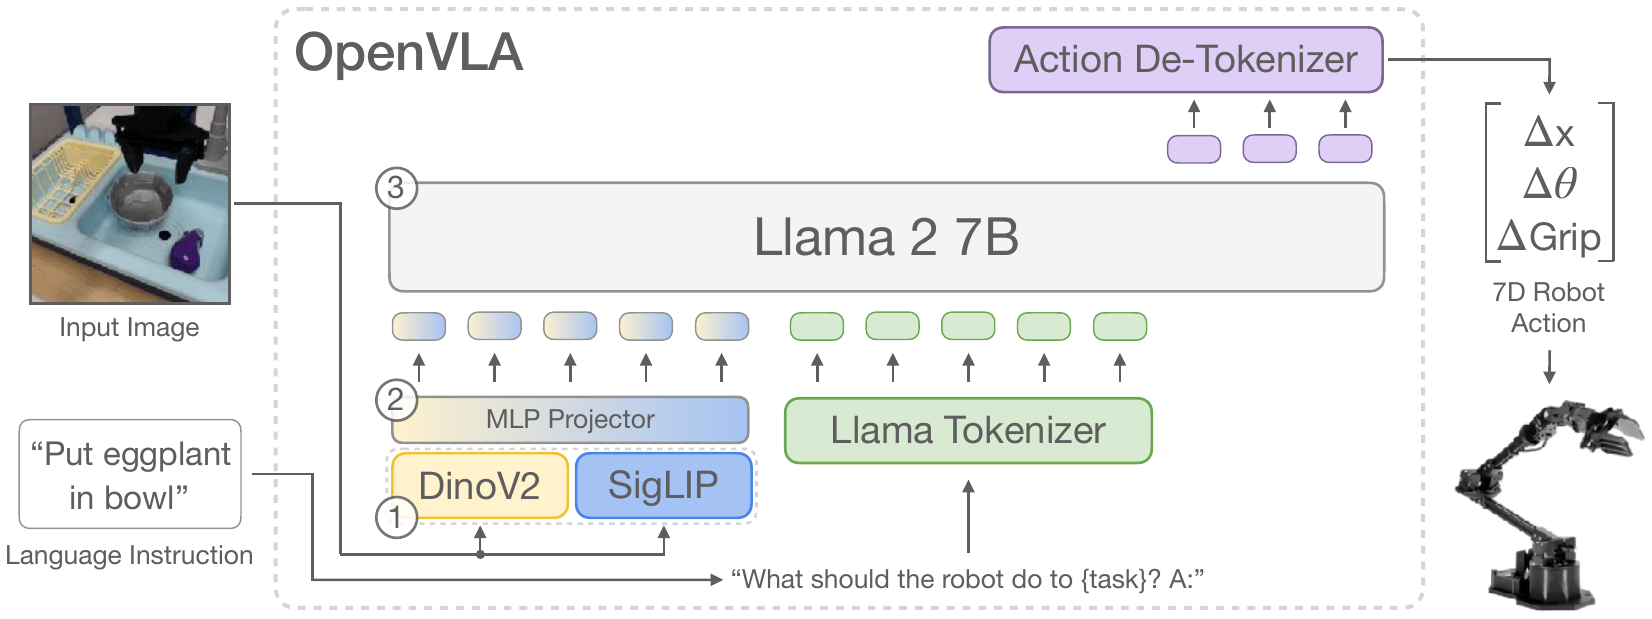

- **视觉编码器，拼接 DinoV2 与 SigLIP 特征**

- **投影器（MLP Projector），把视觉特征映射到语言嵌入空间**

- **LLM 骨干，即 Llama 2 7B 大语言模型**

### 图像 Token

为什么同时需要 **DinoV2 与 SigLIP** ？

SigLIP 提供与语言对齐的**高层语义**（"这是什么物体"），DINOv2 提供细粒度的**低层空间信息**（"它在哪里、朝什么方向"），而机器人控制恰好这两样都要。

| 编码器 | 预训练方式                   | 擅长提供                                  | 对应机器人的需求                       |
| ------ | ---------------------------- | ----------------------------------------- | -------------------------------------- |
| SigLIP | 图文对比学习（与文本对齐）   | 高层语义：物体类别、概念、与指令的对应    | "听懂指令，选对物体"（语言 grounding） |
| DINOv2 | 自监督视觉预训练（只靠图像） | 低层空间/几何结构：位置、形状、细粒度对应 | "精确对齐、抓准位置朝向"（空间推理）   |

同时，**这套双编码器是继承来的，不是 OpenVLA 单独设计的**。OpenVLA 直接采用 Prismatic-7B 作预训练骨干，SigLIP+DINOv2 是 Prismatic 自带的配置；OpenVLA 要做的是把这两个编码器连同整个骨干一起全量微调——而且论文发现 VLA 必须微调视觉编码器、不能冻结。

### 动作 Token

- action -> id：按 P1~P99 将整个区间分成 256 段，区间离散映射成 256 个离散值

- id -> token：取 Llama 词表中使用频率最低的 256 个 token，1 对 1 映射

## 结论

### 优点

- LoRA 微调追平全量微调的性能，却只训练 1.4% 参数，单卡 A100 10–15 小时即可，相比全量微调省 8 倍算力

- 只调最后一层或冻结视觉编码器都明显变差，说明视觉特征必须适配目标场景

### 局限

- 目前只支持单张图像观测；推理约 6Hz，撑不起 50Hz 的高频双臂任务

- 成功率普遍低于 90%

- 基座 VLM 规模的影响、与互联网数据联合训练的效果、什么视觉特征最适合 VLA，这些问题都没有答案。

# OpenVLA-OFT

## OFT（优化微调）

OpenVLA-OFT 不改变 OpenVLA 的预训练来源，而是改变 <mark>微调方式</mark>：并行解码 + 动作分块 + 连续动作 + L1 回归（+ 可选 FiLM）。

```text
OpenVLA（基座模型）
        ↓ 用 OFT 配方微调
OpenVLA-OFT（优化后的下游策略）
        ↓ 在需要更强语言落地时加入 FiLM
OpenVLA-OFT+（ALOHA 版本）
```

比较方向：

- 动作解码方式（自回归 vs. 并行生成）
- 动作表示（离散 vs. 连续）
- 学习目标（下一词元预测 vs. L1 回归 vs. 扩散）

## VLA 微调的关键设计选择

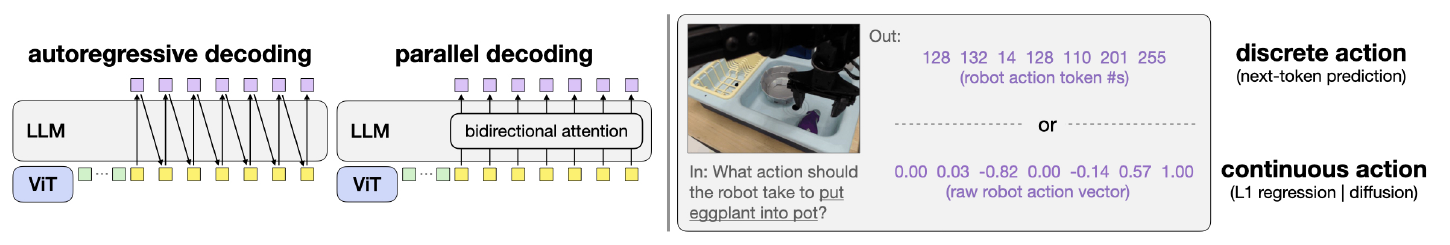

- 左：自回归解码与并行解码
- 右：离散动作词元 + 下一词元预测 与 连续动作 + L1 回归/扩散目标。

<mark>**OpenVLA & OpenVLA-OFT**</mark>

图中三种设计如何组合

原始 OpenVLA 的组合是：

```
自回归解码 + 离散动作 + 下一词元预测
```

论文提出的 OpenVLA-OFT 组合是：

```
并行解码 + 动作分块 + 连续动作 + L1 回归
```

### 自回归解码 -> 并行解码

**自回归解码（autoregressive decoding）**

- 模型一次生成一个动作词元。
- 后一个输出要依赖前一个输出，因此必须顺序执行。
- OpenVLA 每个时间步有 7 个动作维度：3 个位置、3 个姿态、1 个夹爪控制。
- 如果要预测连续 $K$ 个未来时间步，就需要依次生成 $7K$ 个词元，延迟会随动作块长度增加。

**并行解码（parallel decoding）**

- 模型预先放入多个“空的动作槽位”（图中的黄色方块）。
- 将因果注意力改成双向注意力，使所有动作槽位可以同时利用输入信息。
- 一次前向传播直接输出所有动作维度，甚至可以同时输出未来多个时间步的动作块。

因此，动作块大小为 $K$ 时，模型可以一次输出 $7K$ 个动作，而不是逐个生成。这正是论文能够高效使用 **action chunking** 的关键。


### 离散动作 -> 连续动作

**离散动作：**

OpenVLA 原本把每个归一化动作维度划分为 256 个桶。例如：

```
128, 132, 14, 128, 110, 201, 255
```

这些数字不是实际位移，而是动作词元编号。流程是：

```
语言/视觉输入
→ LLM 隐状态
→ 线性投影得到 logits
→ softmax
→ 预测动作词元
```

训练目标类似语言模型的 **next-token prediction**，通常使用交叉熵损失。

优点是可以直接复用语言模型的词元预测结构；缺点是连续动作被量化成有限的 256 个区间，会损失细粒度精度，而且输出维度和词表绑定得较紧。

**连续动作：**机器人动作本质上是“物理量”，而离散动作把它强行当成了“词语”；连续动作则让模型直接预测位移、旋转和夹爪开合等数值。

连续分支直接输出动作向量，例如图中的：

```
0.00, 0.03, -0.82, 0.00, -0.14, 0.57, 1.00
```

论文中这些动作通常先归一化到 \([-1,+1]\)，再由一个 MLP action head 从 LLM 的最终隐状态直接回归。

它可以配合两种训练目标：

- **L1 regression**：直接最小化预测动作与真实动作之间的 L1 距离；
- **Diffusion**：学习逐步去噪生成动作。

L1 回归只需一次直接预测；扩散模型虽然可能有更强的分布建模能力，但推理时需要多次去噪。本文实现中扩散推理使用 50 个 diffusion steps，因此延迟更高。

### 下一词元预测 vs. L1 回归 vs. 扩散

**L1 回归：直接预测连续动作**

L1 回归不再预测动作词元，而是直接输出连续动作向量。

L1 回归本质上是在学习一个“代表性动作”，通常可以理解为条件分布的中位数。它回答的是：
>在当前视觉、语言和机器人状态下，最接近专家示范的动作是多少？

优点
- 不需要动作量化，动作精度更高；
- MLP action head 计算量很小；
- 一次前向传播即可输出整个动作块；
- 训练和推理都比扩散简单、快速；
- 对示范中的少量噪声相对不敏感。

局限

如果同一个输入对应多种都合理的动作，例如机械臂可以从左边拿，也可以从右边拿，L1 可能输出两个动作之间的“中间动作”。这个中间动作可能反而不可执行。

因此，L1 更适合：
- 每个任务的示范策略比较一致；
- 同一状态下通常只有一个主要动作模式；
- 需要实时控制的场景。

**论文最终为什么选择 L1？**

论文的结论不是“L1 在所有任务上都优于扩散”，而是：

对于本文这种策略较一致、任务较聚焦的数据集，高容量的 OpenVLA 已经能够用简单的 L1 回归学到足够好的动作策略，因此没有必要为获得相近性能而承担扩散的计算成本。

### FiLM

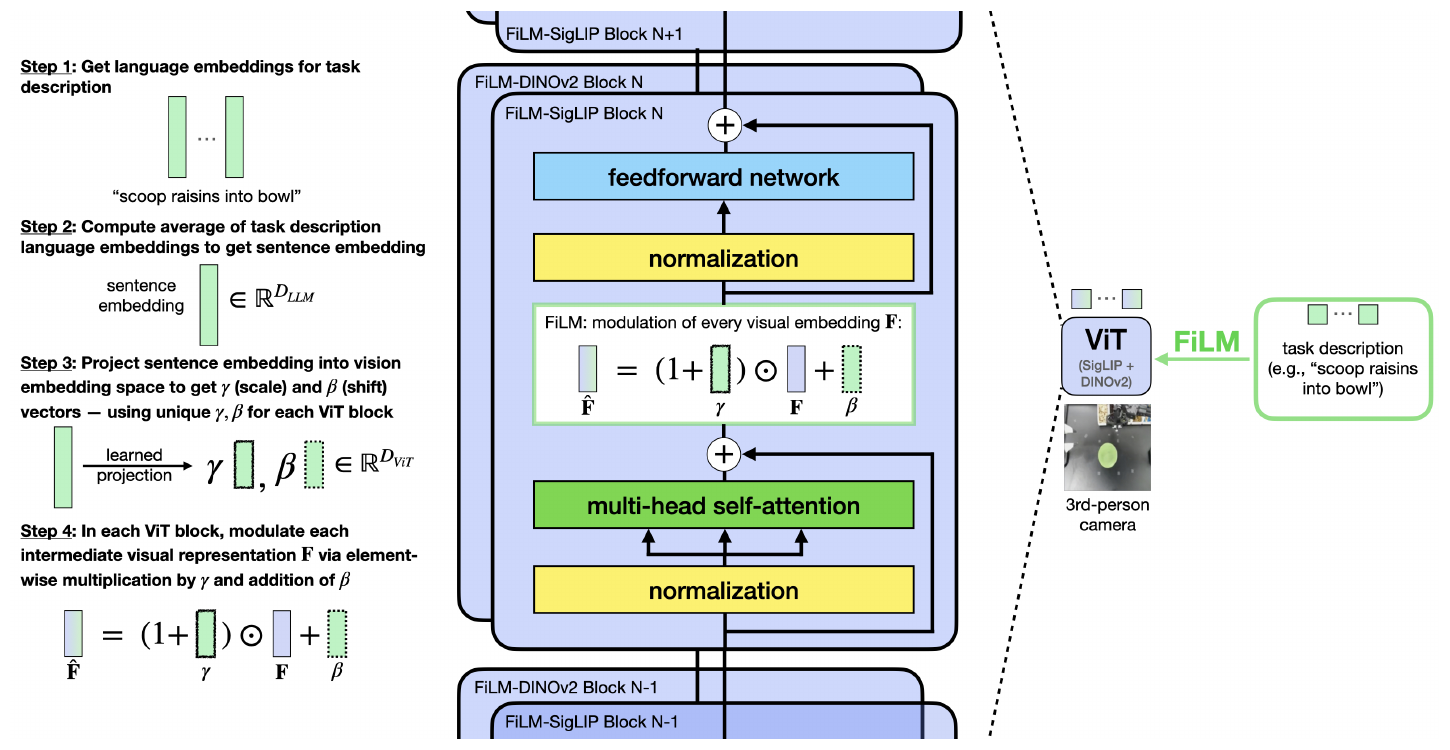

这里写作 **FiLM**，全称是 *Feature-wise Linear Modulation*，即“特征级线性调制”。

一句话理解：

> FiLM 让语言指令在视觉编码阶段就改变“模型看图的方式”。

它们作用在模型的不同位置：

| 机制     | 作用位置   | 解决的问题                             |
| -------- | ---------- | -------------------------------------- |
| 连续动作 | 输出端     | 动作应该表示成连续数值还是离散词元     |
| FiLM     | 视觉编码端 | 模型应该如何根据语言理解图像           |
| 并行解码 | 解码过程   | 一次生成一个动作，还是同时生成一段动作 |

所以，FiLM 不是动作输出方法，也不是加速方法；它主要解决语言指令被模型忽略的问题。

假设图像中有：

- 勺子
- 葡萄干
- 其他食材
- 碗

用户可能下达两种指令：

```
scoop raisins into bowl
scoop green beans into bowl
```

图像可能完全相同，但动作应该不同。

原始做法通常是：

```
图像 → 视觉特征
文字 → 语言特征
视觉特征 + 语言特征 → 动作
```

问题是，模型可能发现：只看腕部相机里的物体位置，就已经能在训练集上取得不错的结果，于是形成“捷径”，没有认真读取语言。论文认为 ALOHA 的多相机输入容易产生这种虚假相关。

FiLM 的作用是让语言更早地进入视觉处理过程：

```
语言指令 → 改变视觉特征 → 再进行动作预测
```

同一张图配不同指令，会产生不同的视觉表示。

论文使用的公式是：

$$ \hat F=(1+\gamma)\odot F+\beta $$

其中：

- $F$：原始视觉特征；
- $\hat F$：经过语言调制后的视觉特征；
- $\gamma$：由语言决定的缩放向量；
- $\beta$：由语言决定的偏移向量；
- $\odot$：逐元素相乘。

可以把它理解为：

- $\gamma$ 决定哪些视觉特征要被放大或减弱；
- $\beta$ 改变这些特征的基准值。

例如，语言指令是“舀葡萄干”，FiLM 可能让与“葡萄干的颜色、形状、位置”相关的特征更突出，让其他特征相对减弱。指令换成“舀绿豆”时，$\gamma$ 和 $\beta$ 也会改变。

注意：FiLM 并不是直接生成一张“葡萄干在哪里”的注意力图，而是在特征层面改变视觉表示，之后由 Transformer 的注意力机制继续寻找相关区域。

## 结论

OFT 在 OpenVLA 上的成功尤其值得注意：尽管 OpenVLA 在预训练时从未接触过双臂机器人或多视角图像输入，用 OFT 微调后它仍能适配这类配置，并追平甚至超过更新的扩散式 VLA（π0 与 RDT-1B）——后者在预训练时已经见过双臂机械臂与多路输入图像。

### 局限

- L1 可能无法很好地表示同一输入对应多种不同动作的多模态分布；
- 扩散可能更适合这类多模态动作，但代价是计算更慢；
- FiLM 对多相机 ALOHA 的语言跟随很重要，但在 LIBERO 中作用较小；
- OFT 对预训练阶段是否同样有效，还需要进一步研究。